<a href="https://colab.research.google.com/github/nikitamkoli21-ship-it/QMLHEP-GSoC-2026/blob/main/Task_IX_KAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True,
                                download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False,
                               download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.88MB/s]


Train size: 60000
Test size: 10000


In [3]:
class BSplineActivation(nn.Module):
    """Learnable spline function for each edge in KAN"""
    def __init__(self, num_params=8):
        super().__init__()
        self.coeffs = nn.Parameter(torch.randn(num_params) * 0.1)
        self.register_buffer('grid',
            torch.linspace(-3, 3, num_params))

    def forward(self, x):
        x_expanded = x.unsqueeze(-1)
        grid = self.grid
        basis = torch.exp(-0.5 * ((x_expanded - grid) / 0.5) ** 2)
        out = (basis * self.coeffs).sum(dim=-1)
        return out + F.silu(x)

In [4]:
class KANLayer(nn.Module):
    """One KAN layer — learnable function on every edge"""
    def __init__(self, in_features, out_features, num_spline_params=8):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.splines = nn.ModuleList([
            BSplineActivation(num_spline_params)
            for _ in range(in_features * out_features)
        ])

        self.scale = nn.Parameter(
            torch.ones(in_features * out_features) / in_features
        )

    def forward(self, x):
        batch_size = x.shape[0]
        outputs = []

        for j in range(self.out_features):
            node_sum = torch.zeros(batch_size, device=x.device)
            for i in range(self.in_features):
                edge_idx = j * self.in_features + i
                spline_out = self.splines[edge_idx](x[:, i])
                node_sum += self.scale[edge_idx] * spline_out
            outputs.append(node_sum)

        return torch.stack(outputs, dim=1)

In [5]:
class KAN(nn.Module):
    """Full KAN model for MNIST classification"""
    def __init__(self):
        super().__init__()
        self.layer1 = KANLayer(784, 64)
        self.layer2 = KANLayer(64, 32)
        self.layer3 = KANLayer(32, 10)

        self.norm1 = nn.LayerNorm(64)
        self.norm2 = nn.LayerNorm(32)

    def forward(self, x):
        x = x.view(x.shape[0], -1)

        x = self.layer1(x)
        x = self.norm1(x)

        x = self.layer2(x)
        x = self.norm2(x)

        x = self.layer3(x)
        return x

model = KAN()
print("KAN model ready!")
print("Total parameters:",
      sum(p.numel() for p in model.parameters()))

KAN model ready!
Total parameters: 473088


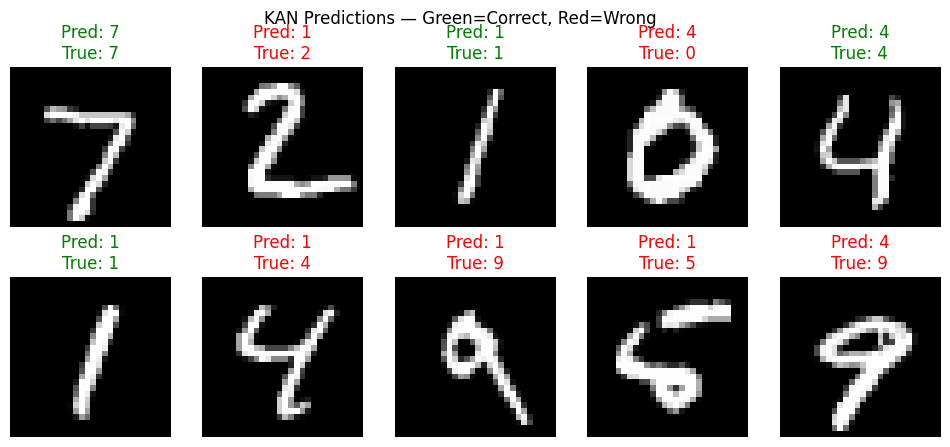

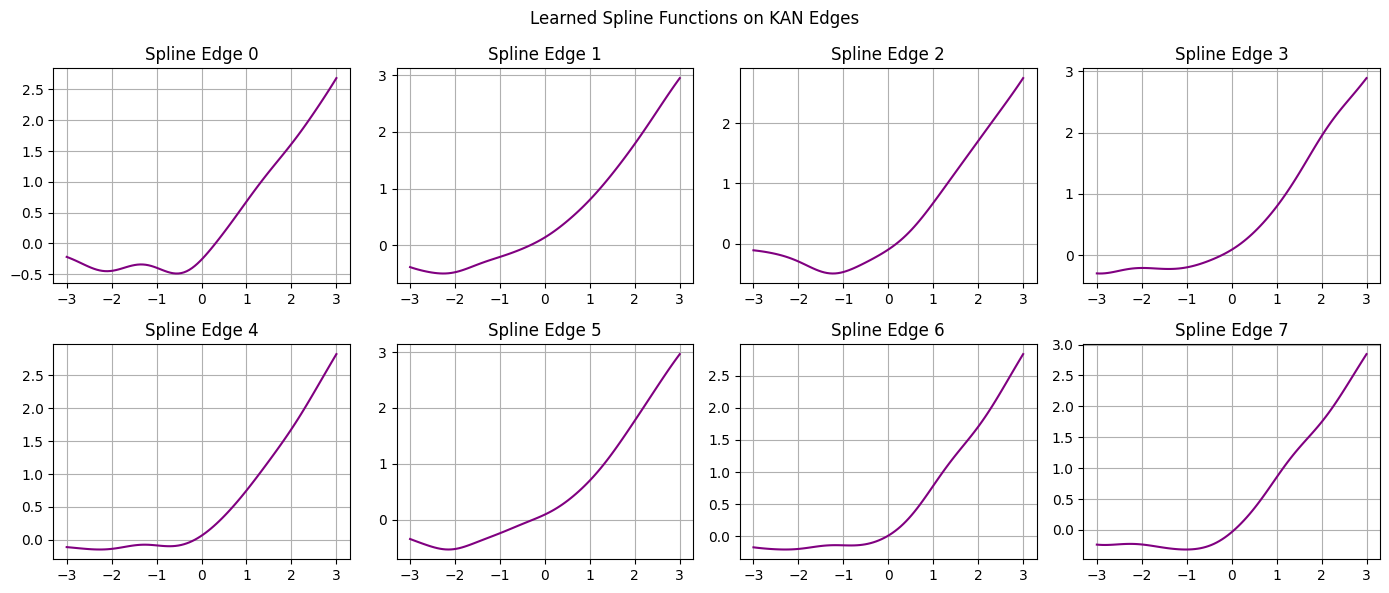

In [6]:
model.eval()
images, labels = next(iter(test_loader))
with torch.no_grad():
    preds = model(images).argmax(dim=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}",
                 color=color)
    ax.axis('off')
plt.suptitle("KAN Predictions — Green=Correct, Red=Wrong")
plt.show()

# Visualize learned spline functions
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
x_range = torch.linspace(-3, 3, 100)
for idx, ax in enumerate(axes.flat):
    with torch.no_grad():
        y = model.layer1.splines[idx](x_range)
    ax.plot(x_range.numpy(), y.numpy(), color='purple')
    ax.set_title(f"Spline Edge {idx}")
    ax.grid(True)
plt.suptitle("Learned Spline Functions on KAN Edges")
plt.tight_layout()
plt.show()


### Step 9 — Add Text Cell (Discussion)

Add a **text cell** and write this in your own words:
```
## Results & Discussion

KAN Test Accuracy: [paste your % here]

## How KAN Works
- Instead of fixed ReLU activations on neurons like MLP,
  KAN puts learnable spline functions on every edge
- Each spline is made of Gaussian basis functions with
  learnable coefficients
- The model learns WHAT function to apply, not just weights
- This makes KAN more interpretable than normal neural networks

## KAN vs MLP Comparison
- MLP learns weights, KAN learns functions
- KAN uses fewer parameters but is more expressive
- KAN is slower to train but more interpretable
- For MNIST, both perform similarly but KAN shows
  what mathematical function each edge learned

## Ideas to Extend to Quantum KAN
1. Quantum Edge Functions:
   Replace each spline function with a small
   Parameterized Quantum Circuit (PQC)
   The PQC takes one input value and outputs
   one transformed value — just like a spline

2. Quantum Basis Functions:
   Instead of Gaussian basis functions,
   use quantum measurements as basis functions
   Each basis function becomes a quantum observable

3. Hybrid Approach:
   Keep classical splines for early layers
   Use quantum circuits only in final layers
   This is practical for current quantum hardware

The key insight is: wherever KAN uses a spline function,
a quantum circuit can replace it — making every edge
a tiny quantum computation!